## Logging Configuration


In [90]:
import logging

# Configure logging to write to a file named 'forestfires.log'
logging.basicConfig(
    filename='forestfires.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w' # 'w' overwrites the log file each time, 'a' appends
)

logging.info('Logging configured successfully.')

 ## Loading, cleaning, and transforming data

In [91]:
import pandas as pd
import numpy as np

df = pd.read_csv("forestfires.csv")

# clean column names by stripping whitespace and converting to lowercase
df.columns = df.columns.str.strip().str.lower()

# remove duplicate rows from the df
df = df.drop_duplicates()

# create a 'season' feature based on month using a mapping
df['season'] = df['month'].map({
    'dec':'winter','jan':'winter','feb':'winter',
    'mar':'spring','apr':'spring','may':'spring',
    'jun':'summer','jul':'summer','aug':'summer',
    'sep':'autumn','oct':'autumn','nov':'autumn'
})

# Create 'season' feature using a function
def get_season(month):
    """
    Determines the season based on the given month.

    Args:
        month (str): The three-letter abbreviation of the month (e.g., 'jan', 'feb').

    Returns:
        str: The corresponding season ('winter', 'spring', 'summer', 'autumn').
    """
    if month in ['dec', 'jan', 'feb']:
        return 'winter'
    elif month in ['mar', 'apr', 'may']:
        return 'spring'
    elif month in ['jun', 'jul', 'aug']:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)

# Create 'log_area' feature by applying a log1p transformation to 'area'
# log1p(x) calculates log(1+x), which is useful for data with many zeros
df['log_area'] = np.log1p(df['area'])

print(df.columns)
print(df.head)
df.to_csv("df.csv", index=False)

Index(['x', 'y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh',
       'wind', 'rain', 'area', 'season', 'log_area'],
      dtype='object')
<bound method NDFrame.head of      x  y month  day  ffmc    dmc     dc   isi  temp  rh  wind  rain   area  \
0    7  5   mar  fri  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.00   
1    7  4   oct  tue  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.00   
2    7  4   oct  sat  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.00   
3    8  6   mar  fri  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.00   
4    8  6   mar  sun  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.00   
..  .. ..   ...  ...   ...    ...    ...   ...   ...  ..   ...   ...    ...   
512  4  3   aug  sun  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0   6.44   
513  2  4   aug  sun  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0  54.29   
514  7  4   aug  sun  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0  11.16   
515  1  4   aug  sat  94.4  1

## Making relational tables

In [92]:
try:
    # create dimension tables from the main DataFrame

    # locations table: extracts unique x and y coordinates, assigns a location_id
    locations = df[["x", "y"]].drop_duplicates().reset_index(drop=True)
    locations["location_id"] = locations.index + 1
    locations = locations[["location_id", "x", "y"]]
    logging.info("Created 'locations' dimension table.")

    # time_info table: extracts unique month, day, and season combinations, assigns a time_id
    time_info = df[["month", "day", "season"]].drop_duplicates().reset_index(drop=True)
    time_info["time_id"] = time_info.index + 1
    time_info = time_info[["time_id", "month", "day", "season"]]
    logging.info("Created 'time_info' dimension table.")

    # weather table: extracts unique weather conditions (temp, rh, wind, rain), assigns a weather_id
    weather = df[["temp", "rh", "wind", "rain"]].drop_duplicates().reset_index(drop=True)
    weather["weather_id"] = weather.index + 1
    weather = weather[["weather_id", "temp", "rh", "wind", "rain"]]
    logging.info("Created 'weather' dimension table.")

    # fire_indices table: extracts unique fire weather index components (ffmc, dmc, dc, isi), assigns an index_id
    fire_indices = df[["ffmc", "dmc", "dc", "isi"]].drop_duplicates().reset_index(drop=True)
    fire_indices["index_id"] = fire_indices.index + 1
    fire_indices = fire_indices[["index_id", "ffmc", "dmc", "dc", "isi"]]
    logging.info("Created 'fire_indices' dimension table.")

    # Merge IDs back into main data to prepare for fact table creation
    df_rel = df.merge(locations, on=["x", "y"], how="left")
    df_rel = df_rel.merge(time_info, on=["month", "day", "season"], how="left")
    df_rel = df_rel.merge(weather, on=["temp", "rh", "wind", "rain"], how="left")
    df_rel = df_rel.merge(fire_indices, on=["ffmc", "dmc", "dc", "isi"], how="left")
    logging.info("Merged dimension IDs back into the main DataFrame.")

    # Create fact table: fires, containing foreign keys and measured values
    fires = df_rel[[
        "location_id",
        "time_id",
        "weather_id",
        "index_id",
        "area",
        "log_area"
    ]].copy()

    # Add a unique record_id for each fire event
    fires = fires.reset_index().rename(columns={"index": "record_id"})
    fires["record_id"] = fires["record_id"] + 1

    fires = fires[[
        "record_id",
        "location_id",
        "time_id",
        "weather_id",
        "index_id",
        "area",
        "log_area"
    ]]
    logging.info("Created 'fires' fact table.")

    # Save relational tables to CSV files for persistence
    locations.to_csv("locations.csv", index=False)
    time_info.to_csv("time_info.csv", index=False)
    weather.to_csv("weather.csv", index=False)
    fire_indices.to_csv("fire_indices.csv", index=False)
    fires.to_csv("fires.csv", index=False)
    logging.info("Saved all relational tables to CSV files.")

    # preview the head of each created table
    print("locations")
    print(locations.head(), "\n")

    print("time_info")
    print(time_info.head(), "\n")

    print("weather")
    print(weather.head(), "\n")

    print("fire_indices")
    print(fire_indices.head(), "\n")

    print("fires")
    print(fires.head())
    print(fires.shape)
    logging.info("Printed head of all created tables.")

except Exception as e:
    logging.error(f"Error in making relational tables: {e}")

locations
   location_id  x  y
0            1  7  5
1            2  7  4
2            3  8  6
3            4  6  5
4            5  5  5 

time_info
   time_id month  day  season
0        1   mar  fri  spring
1        2   oct  tue  autumn
2        3   oct  sat  autumn
3        4   mar  sun  spring
4        5   aug  sun  summer 

weather
   weather_id  temp  rh  wind  rain
0           1   8.2  51   6.7   0.0
1           2  18.0  33   0.9   0.0
2           3  14.6  33   1.3   0.0
3           4   8.3  97   4.0   0.2
4           5  11.4  99   1.8   0.0 

fire_indices
   index_id  ffmc   dmc     dc  isi
0         1  86.2  26.2   94.3  5.1
1         2  90.6  35.4  669.1  6.7
2         3  90.6  43.7  686.9  6.7
3         4  91.7  33.3   77.5  9.0
4         5  89.3  51.3  102.2  9.6 

fires
   record_id  location_id  time_id  weather_id  index_id  area  log_area
0          1            1        1           1         1   0.0       0.0
1          2            2        2           2         2   0.

## Data Preparation: loading into duckdb

In [93]:
import duckdb
try:
    # Connect to DuckDB database file
    con = duckdb.connect("forestfires.duckdb")
    logging.info("Connected to DuckDB database: forestfires.duckdb.")

    # register pandas dfs as temporary DuckDB tables
    con.register("locations_df", locations)
    con.register("time_info_df", time_info)
    con.register("weather_df", weather)
    con.register("fire_indices_df", fire_indices)
    con.register("fires_df", fires)
    logging.info("Registered pandas DataFrames as temporary DuckDB tables.")

    # create persistent tables in DuckDB from the registered dfs
    con.execute("CREATE OR REPLACE TABLE locations AS SELECT * FROM locations_df")
    con.execute("CREATE OR REPLACE TABLE time_info AS SELECT * FROM time_info_df")
    con.execute("CREATE OR REPLACE TABLE weather AS SELECT * FROM weather_df")
    con.execute("CREATE OR REPLACE TABLE fire_indices AS SELECT * FROM fire_indices_df")
    con.execute("CREATE OR REPLACE TABLE fires AS SELECT * FROM fires_df")
    logging.info("Created persistent tables in DuckDB from temporary tables.")

except Exception as e:
    logging.error(f"Error during DuckDB integration: {e}")

## Queries

In [94]:
try:
    # SQL query to calculate fire statistics grouped by season
    query_season_summary = """
    SELECT
        t.season,              -- Select the season
        COUNT(*) AS n_fires,   -- Count the number of fires in each season
        AVG(f.area) AS mean_area, -- Calculate the average burned area
        AVG(f.log_area) AS mean_log_area, -- Calculate the average log-transformed burned area
        MAX(f.area) AS max_area    -- Find the maximum burned area
    FROM fires f                 -- From the fires fact table (aliased as f)
    JOIN time_info t             -- Join with the time_info dimension table (aliased as t)
        ON f.time_id = t.time_id -- On the common time_id column
    GROUP BY t.season             -- Group the results by season
    ORDER BY mean_log_area DESC  -- Order the results by mean log-transformed area in descending order
    """
    logging.info("Defined SQL query for seasonal summary.")

    # Execute the SQL query and load the results into a pandas DataFrame
    season_summary = con.execute(query_season_summary).df()
    logging.info("Executed seasonal summary query and loaded results into DataFrame.")

    print("SEASON SUMMARY")
    print(season_summary)
    logging.info("Printed seasonal summary.")

except Exception as e:
    logging.error(f"Error executing seasonal summary query: {e}")

SEASON SUMMARY
   season  n_fires  mean_area  mean_log_area  max_area
0  winter       31   7.918387       1.448442     51.78
1  autumn      188  16.945213       1.239235   1090.84
2  summer      230  12.422261       1.049240    746.28
3  spring       64   5.079688       0.809492     61.13


In [95]:
try:
    # SQL query to join all relevant tables for model training
    query_model_data = """
    SELECT
        f.record_id,   -- Unique identifier for each fire record
        l.x,           -- X-coordinate of the fire location
        l.y,           -- Y-coordinate of the fire location
        t.month,       -- Month of the fire
        t.day,         -- Day of the week of the fire
        t.season,      -- Season of the fire
        w.temp,        -- Temperature at the time of the fire
        w.rh,          -- Relative humidity at the time of the fire
        w.wind,        -- Wind speed at the time of the fire
        w.rain,        -- Rain at the time of the fire
        i.ffmc,        -- Fine Fuel Moisture Code
        i.dmc,         -- Duff Moisture Code
        i.dc,          -- Drought Code
        i.isi,         -- Initial Spread Index
        f.log_area     -- Log-transformed burned area (target variable)
    FROM fires f
    JOIN locations l
        ON f.location_id = l.location_id
    JOIN time_info t
        ON f.time_id = t.time_id
    JOIN weather w
        ON f.weather_id = w.weather_id
    JOIN fire_indices i
        ON f.index_id = i.index_id
    """
    logging.info("Defined SQL query for modeling data.")

    # Execute the SQL query and load the results into a df for modeling
    df_model = con.execute(query_model_data).df()
    logging.info("Executed modeling data query and loaded results into df_model DataFrame.")

    print("MODEL DATA")
    print(df_model.head())
    print(df_model.shape)
    logging.info("Printed head and shape of df_model.")

except Exception as e:
    logging.error(f"Error executing modeling data query: {e}")

MODEL DATA
   record_id  x  y month  day  season  temp  rh  wind  rain  ffmc   dmc  \
0          1  7  5   mar  fri  spring   8.2  51   6.7   0.0  86.2  26.2   
1          2  7  4   oct  tue  autumn  18.0  33   0.9   0.0  90.6  35.4   
2          3  7  4   oct  sat  autumn  14.6  33   1.3   0.0  90.6  43.7   
3          4  8  6   mar  fri  spring   8.3  97   4.0   0.2  91.7  33.3   
4          5  8  6   mar  sun  spring  11.4  99   1.8   0.0  89.3  51.3   

      dc  isi  log_area  
0   94.3  5.1       0.0  
1  669.1  6.7       0.0  
2  686.9  6.7       0.0  
3   77.5  9.0       0.0  
4  102.2  9.6       0.0  
(513, 15)


## Modeling

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    # prep features for modeling

    # one-hot encode categorical columns (month, day, season)
    # drop_first=True prevents multicollinearity by dropping the first category
    df_model_encoded = pd.get_dummies(
        df_model,
        columns=["month", "day", "season"],
        drop_first=True
    )
    logging.info("One-hot encoded categorical features.")

    # define features (X) and target (y)
    X = df_model_encoded.drop(columns=["record_id", "log_area"]) # Drop record_id and target variable
    y = df_model_encoded["log_area"] # Target variable

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    logging.info(f"Defined features (X) with shape {X.shape} and target (y) with shape {y.shape}.")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2, # 20% of data for testing
        random_state=42 # for reproducibility
    )
    logging.info("Data split into training and testing sets.")

    # Random forest regression model: Initialize and train the model
    rf_model = RandomForestRegressor(
        n_estimators=200, # Number of trees in the forest
        max_depth=8,      # Maximum depth of each tree
        random_state=42
    )

    rf_model.fit(X_train, y_train) # Train the model on the training data
    logging.info("Random Forest Regressor model trained successfully.")

    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)
    logging.info("Predictions made on the test set.")

    # Evaluate by calculating RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("Random Forest Regression Results")
    print("RMSE:", rmse)
    print("R^2:", r2)
    logging.info(f"Random Forest Regression evaluated: RMSE={rmse:.4f}, R^2={r2:.4f}.")

    # Extract and display the top 10 most important features
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

    print(feature_importance.head(10))
    logging.info("Extracted and printed top 10 feature importances for Random Forest model.")

except Exception as e:
    logging.error(f"Error during Random Forest Regression modeling: {e}")

X shape: (513, 30)
y shape: (513,)
Random Forest Regression Results
RMSE: 1.3051900732819555
R^2: -0.019734066008826545
    feature  importance
2      temp    0.175388
3        rh    0.119846
7       dmc    0.104739
4      wind    0.099626
0         x    0.083573
8        dc    0.081821
9       isi    0.081711
6      ffmc    0.073029
1         y    0.060800
22  day_sat    0.016181


In [97]:
# Initialize and train a Linear Regression model for comparison
from sklearn.linear_model import LinearRegression
import logging
import numpy as np # Ensure numpy is imported for np.sqrt
from sklearn.metrics import mean_squared_error, r2_score

try:
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train) # Train the model on the training data
    logging.info("Linear Regression model trained successfully.")

    # Make predictions using the LR model
    y_pred_lr = lr_model.predict(X_test)
    logging.info("Predictions made on the test set using Linear Regression.")

    # Evaluate model using RMSE and R-squared
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2_lr = r2_score(y_test, y_pred_lr)

    print("Linear Regression Results")
    print("RMSE:", rmse_lr)
    print("R^2:", r2_lr)
    logging.info(f"Linear Regression evaluated: RMSE={rmse_lr:.4f}, R^2={r2_lr:.4f}.")

except Exception as e:
    logging.error(f"Error during Linear Regression modeling: {e}")

Linear Regression Results
RMSE: 1.2667937337256057
R^2: 0.03938090180180531


## Analysis Rationale

The modeling approach focused on predicting wildfire severity (log-transformed burned area) using environmental and meteorological variables. A Random Forest model was selected to capture potential non-linear relationships and interactions between variables, while a Linear Regression model was used as a comparison due to its simplicity and interpretability.

Both models demonstrated low predictive performance, with R² values near zero, indicating that the selected variables explain very little of the variation in wildfire severity. This outcome suggests that while the included features are theoretically relevant, they are insufficient on their own to capture the complexity of wildfire behavior. Wildfires are influenced by many additional factors not present in the dataset, such as human activity, terrain, vegetation type, and ignition sources.

The use of a log transformation on burned area was a key modeling decision to address the strong right skew in the original variable and stabilize variance. However, even after this transformation, the models struggled to identify meaningful predictive patterns.

Overall, this analysis emphasizes that poor model performance can be informative. It reveals gaps in the dataset and underscores the importance of feature selection, domain knowledge, and data collection in building effective predictive models for complex environmental systems.

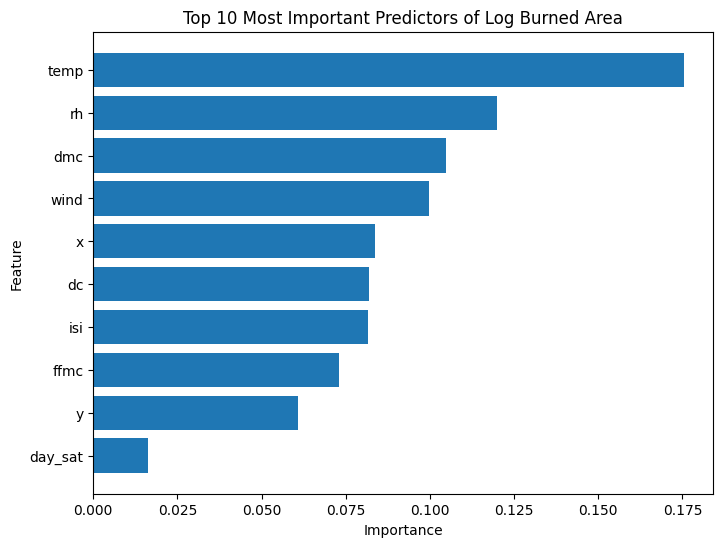

In [98]:
import matplotlib.pyplot as plt

try:
    # Top 10 feature importances from the Random Forest model
    top_features = feature_importance.head(10).sort_values("importance")

    plt.figure(figsize=(8, 6))
    plt.barh(top_features["feature"], top_features["importance"]) # bar chart of feature importances
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 10 Most Important Predictors of Log Burned Area")
    plt.show()
    logging.info("Generated Top 10 Feature Importances plot.")

except Exception as e:
    logging.error(f"Error generating Top 10 Feature Importances plot: {e}")

## Visualization Rationale

The visualization presents the top predictors of wildfire severity using feature importance scores from the Random Forest model.

The feature importance plot shows that temperature is the most influential predictor of wildfire severity, followed by relative humidity and drought-related indices such as DMC. This suggests that hotter, drier conditions are most strongly associated with larger burned areas, which aligns with established wildfire behavior where heat and dryness increase fire spread potential.

Wind speed also appears as an important factor, reflecting its role in accelerating fire spread, while indices like DC, ISI, and FFMC contribute moderately, indicating that fuel dryness and fire weather conditions still play a meaningful role but are less dominant than temperature and humidity. Spatial variables (x and y) have some influence, which may capture location-specific patterns in the dataset, though they are less interpretable from a physical standpoint.

The very low importance of variables like day of the week suggests that temporal factors unrelated to weather have minimal impact on wildfire severity in this dataset. Overall, the visualization reinforces that environmental conditions—especially heat, dryness, and wind—are the primary drivers of wildfire size, even though the model as a whole has limited predictive power.

In [99]:
!jupyter nbconvert --to markdown datapipeline.ipynb

[NbConvertApp] Converting notebook datapipeline.ipynb to markdown
[NbConvertApp] Support files will be in datapipeline_files/
[NbConvertApp] Making directory datapipeline_files
[NbConvertApp] Writing 19061 bytes to datapipeline.md
